In [22]:
##مرحبًا اسمي فارس الشخانبة، ومهتم بعلم البيانات
##في هذا النموذج هدفي تمييز حرف الباء بحالتين، باء منفردة وباء أول السطر

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import os
from PIL import Image, ImageOps
import cv2

base_path = r'C:\Users\fares\Desktop\محتوى سياق\قواعد بيانات سياق\حرف الباء'
isolated_path = os.path.join(base_path, 'حرف الباء مفردًا')
beginning_path = os.path.join(base_path, 'حرف الباء أول الكلمة')
IMG_SIZE = 28

def standardize_image(img_path):
    img = Image.open(img_path).convert('L')
    
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
    
    img = ImageOps.autocontrast(img, cutoff=2)
    
    img_array = np.array(img, dtype=np.float32)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    img_array = clahe.apply(np.uint8(img_array)).astype(np.float32)
    
    return img_array

def load_images_from_folder(folder_path, label):
    images = []
    labels = []
    failed_count = 0
    
    if not os.path.exists(folder_path):
        print(f"خطأ: المجلد غير موجود: {folder_path}")
        return np.array(images), np.array(labels)
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp')):
            img_path = os.path.join(folder_path, filename)
            try:
                img_array = standardize_image(img_path)
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                failed_count += 1
                print(f"تحذير: فشل تحميل {filename}")
    
    print(f"تم تحميل {len(images)} صورة (فشل {failed_count})")
    return np.array(images), np.array(labels)

print("تحميل البيانات...\n")
isolated_images, isolated_labels = load_images_from_folder(isolated_path, label=0)
beginning_images, beginning_labels = load_images_from_folder(beginning_path, label=1)

X = np.concatenate([isolated_images, beginning_images], axis=0)
y = np.concatenate([isolated_labels, beginning_labels], axis=0)

if len(X) == 0:
    print("خطأ: لم يتم تحميل أي صور!")
    exit()

print("\nShape of X:", X.shape)
print(f"عدد صور الفئة الأولى: {np.sum(y == 0)}")
print(f"عدد صور الفئة الثانية: {np.sum(y == 1)}")

X = X / 255.0

X_mean = X.mean()
X_std = X.std()
X = (X - X_mean) / (X_std + 1e-8)

print(f"\nالمتوسط: {X.mean():.4f}, الانحراف المعياري: {X.std():.4f}")
print("Shape of X after standardization:", X.shape)

X = X.reshape(-1, 28, 28, 1)
print("Shape of X after reshaping:", X.shape)

y = to_categorical(y, num_classes=2)
print("Shape of y after one-hot encoding:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1))
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1))

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print("\n" + "="*60)
print("توحيد وتهيئة البيانات اكتمل بنجاح")
print("="*60)
print(f"\nإحصائيات التوحيد:")
print(f"  - Contrast Normalization: تم")
print(f"  - CLAHE Enhancement: تم")
print(f"  - Standardization: تم")
print(f"  - الصور موحدة وجاهزة للتدريب")

تحميل البيانات...

تم تحميل 109 صورة (فشل 0)
تم تحميل 122 صورة (فشل 0)

Shape of X: (231, 28, 28)
عدد صور الفئة الأولى: 109
عدد صور الفئة الثانية: 122

المتوسط: -0.0000, الانحراف المعياري: 1.0000
Shape of X after standardization: (231, 28, 28)
Shape of X after reshaping: (231, 28, 28, 1)
Shape of y after one-hot encoding: (231, 2)

X_train shape: (147, 28, 28, 1)
X_val shape: (37, 28, 28, 1)
X_test shape: (47, 28, 28, 1)

توحيد وتهيئة البيانات اكتمل بنجاح

إحصائيات التوحيد:
  - Contrast Normalization: تم
  - CLAHE Enhancement: تم
  - Standardization: تم
  - الصور موحدة وجاهزة للتدريب


In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(28, 28, 1)),
    
    Conv2D(16, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),
    
    Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),
    
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

optimizer = Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ملخص النموذج:")
model.summary()
print("\n")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

augmentation = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=8,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

print("جاري التدريب...\n")
history = model.fit(
    augmentation.flow(X_train, y_train, batch_size=16),
    epochs=150,
    validation_data=val_dataset,
    callbacks=[early_stop, reduce_lr],
    steps_per_epoch=len(X_train) // 16,
    verbose=1
)

print("\nالتقييم:")
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=0)
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=0)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\n" + "="*60)
print("الفرق بين Validation و Test:")
print(f"Gap: {(val_accuracy - test_accuracy) * 100:.2f}%")
if abs(val_accuracy - test_accuracy) < 0.05:
    print("النموذج متوازن - لا يحفظ البيانات")
else:
    print("النموذج يحفظ البيانات - Overfitting")
print("="*60)

model.save('arabic_ba_model.keras')
print("\nتم حفظ النموذج")

ملخص النموذج:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 28, 28, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 14, 14, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │         100,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 105,538 (412.26 KB)

 Trainable params: 105,442 (411.88 KB)

 Non-trainable params: 96 (384.00 B)



جاري التدريب...

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5115 - loss: 2.0963 - val_accuracy: 0.7297 - val_loss: 0.7864 - learning_rate: 5.0000e-04
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 1.6123 - val_accuracy: 0.7297 - val_loss: 0.7759 - learning_rate: 5.0000e-04
Epoch 3/150
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5150 - loss: 1.9144

C:\Users\fares\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5649 - loss: 1.6169 - val_accuracy: 0.8108 - val_loss: 0.7153 - learning_rate: 5.0000e-04
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.1104 - val_accuracy: 0.7838 - val_loss: 0.7103 - learning_rate: 5.0000e-04
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6031 - loss: 1.3388 - val_accuracy: 0.7297 - val_loss: 0.6903 - learning_rate: 5.0000e-04
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6875 - loss: 0.9459 - val_accuracy: 0.7297 - val_loss: 0.6875 - learning_rate: 5.0000e-04
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6947 - loss: 0.9801 - val_accuracy: 0.7838 - val_loss: 0.6616 - learning_rate: 5.0000e-04
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6875 - loss: 0.7283 - val_accuracy: 0.7838 - val_loss: 0.6573 - learning_rate: 5.0000e-04
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6336 - loss: 1.1826 - val_a

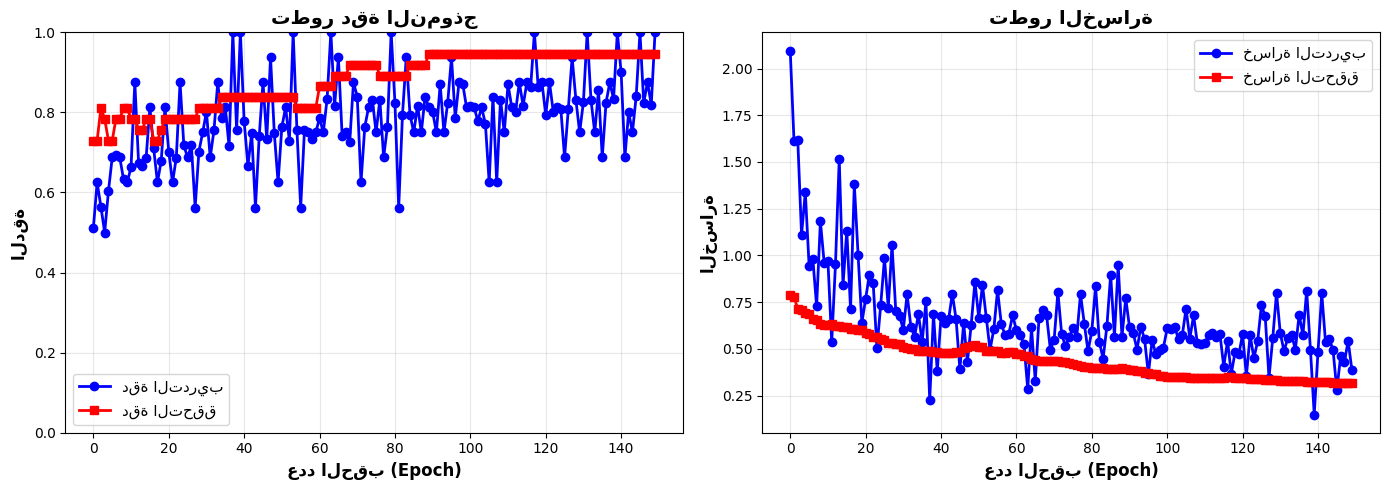

التنبؤ على بيانات الاختبار...



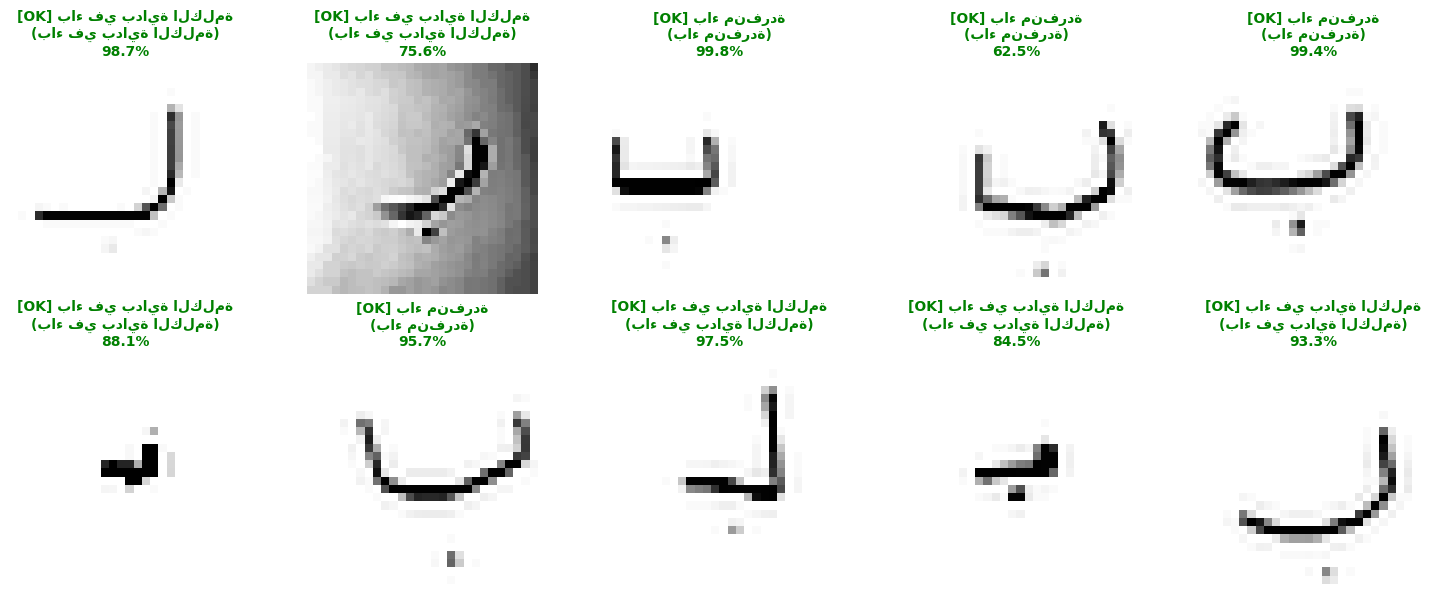

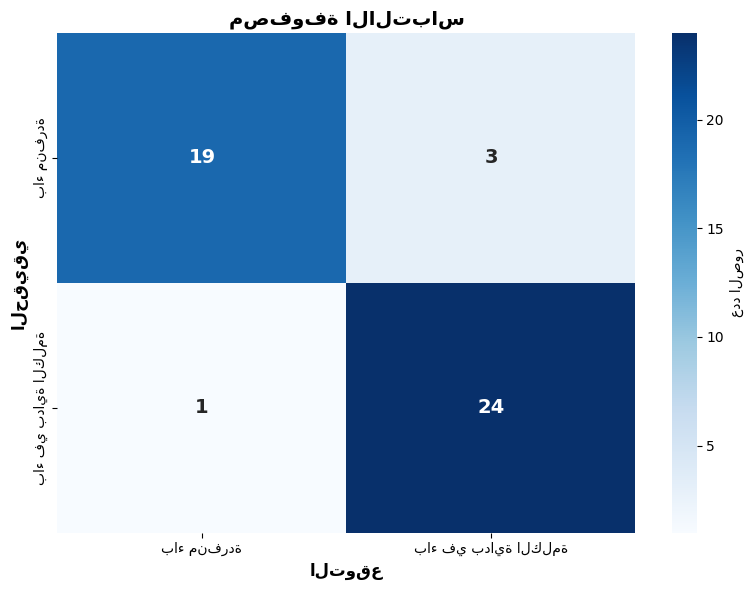


تقييم شامل لأداء النموذج

المقاييس الرئيسية:
   الدقة (Accuracy):    91.49%
   الدقة الموضعية (Precision): 91.75%
   الاستدعاء (Recall):  91.49%
   F1 Score:            91.45%


التقييم: [OK] ممتازة
النصيحة: النموذج يتعلم بشكل ممتاز ويميز بين الحالتين بفعالية!


الصور الصحيحة: 43 من 47

التقرير التفصيلي للتصنيف
                     precision    recall  f1-score   support

         باء منفردة     0.9500    0.8636    0.9048        22
باء في بداية الكلمة     0.8889    0.9600    0.9231        25

           accuracy                         0.9149        47
          macro avg     0.9194    0.9118    0.9139        47
       weighted avg     0.9175    0.9149    0.9145        47


الأخطاء (4 من 47):


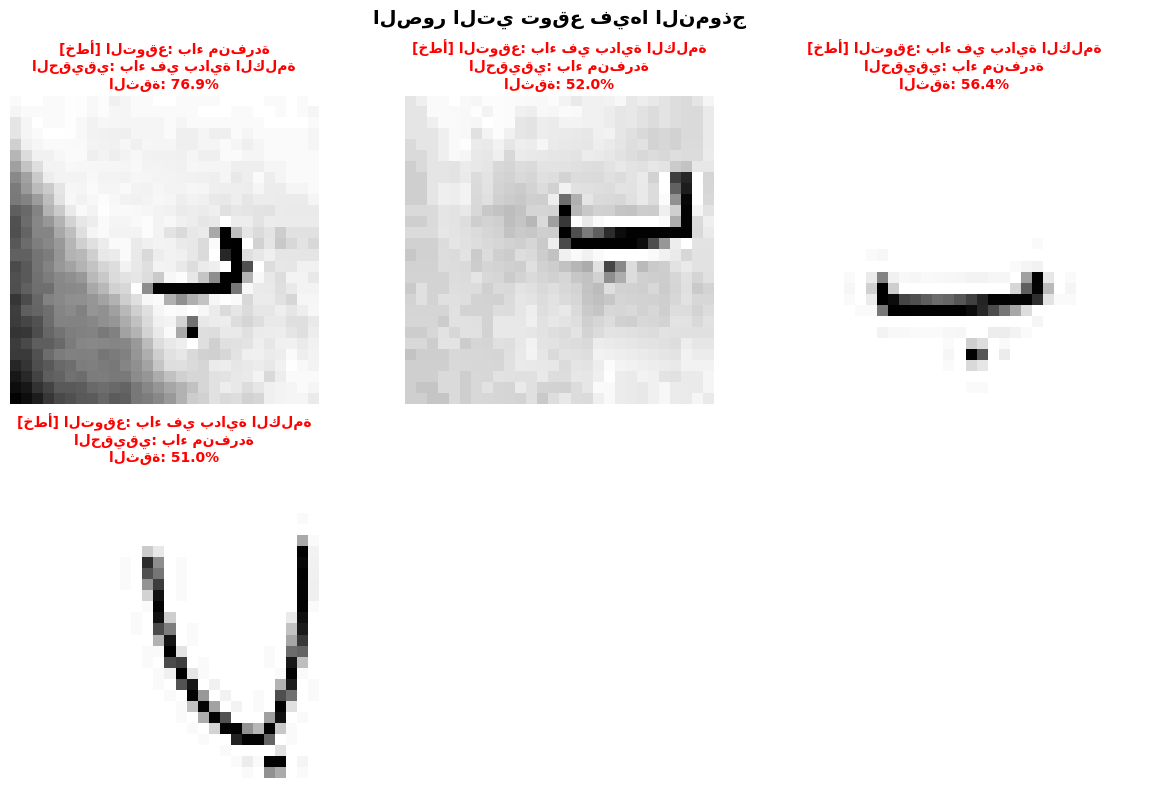


حفظ النموذج...
[OK] تم حفظ النموذج: arabic_ba_model.keras


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], 'b-o', label='دقة التدريب', linewidth=2, markersize=6)
axes[0].plot(history.history['val_accuracy'], 'r-s', label='دقة التحقق', linewidth=2, markersize=6)
axes[0].set_xlabel('عدد الحقب (Epoch)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('الدقة', fontsize=12, fontweight='bold')
axes[0].set_title('تطور دقة النموذج', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(history.history['loss'], 'b-o', label='خسارة التدريب', linewidth=2, markersize=6)
axes[1].plot(history.history['val_loss'], 'r-s', label='خسارة التحقق', linewidth=2, markersize=6)
axes[1].set_xlabel('عدد الحقب (Epoch)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('الخسارة', fontsize=12, fontweight='bold')
axes[1].set_title('تطور الخسارة', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("التنبؤ على بيانات الاختبار...\n")
predictions = model.predict(X_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

class_names = ['باء منفردة', 'باء في بداية الكلمة']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(min(10, len(X_test))):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    
    true_label = class_names[true_labels[i]]
    pred_label = class_names[predicted_labels[i]]
    confidence = np.max(predictions[i]) * 100
    
    color = 'green' if true_labels[i] == predicted_labels[i] else 'red'
    symbol = '[OK]' if true_labels[i] == predicted_labels[i] else '[خطأ]'
    
    axes[i].set_title(
        f"{symbol} {pred_label}\n({true_label})\n{confidence:.1f}%",
        color=color,
        fontsize=10,
        fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'عدد الصور'},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('التوقع', fontsize=12, fontweight='bold')
plt.ylabel('الحقيقي', fontsize=12, fontweight='bold')
plt.title('مصفوفة الالتباس', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

accuracy = np.mean(predicted_labels == true_labels) * 100
precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0) * 100
recall = recall_score(true_labels, predicted_labels, average='weighted', zero_division=0) * 100
f1 = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0) * 100

print("\n" + "="*60)
print("تقييم شامل لأداء النموذج")
print("="*60)
print(f"\nالمقاييس الرئيسية:")
print(f"   الدقة (Accuracy):    {accuracy:.2f}%")
print(f"   الدقة الموضعية (Precision): {precision:.2f}%")
print(f"   الاستدعاء (Recall):  {recall:.2f}%")
print(f"   F1 Score:            {f1:.2f}%")
print("\n" + "="*60)

if accuracy >= 90:
    status = "[OK] ممتازة"
    advice = "النموذج يتعلم بشكل ممتاز ويميز بين الحالتين بفعالية!"
elif accuracy >= 80:
    status = "[OK] جيدة جداً"
    advice = "النموذج يعمل بشكل جيد ويمكن تحسينه بإضافة بيانات."
elif accuracy >= 70:
    status = "[OK] جيدة"
    advice = "النموذج يعمل بشكل مقبول لكن يحتاج تحسينات."
else:
    status = "[خطأ] ضعيفة"
    advice = "النموذج يحتاج إلى تحسينات كبيرة."

print(f"\nالتقييم: {status}")
print(f"النصيحة: {advice}")
print("\n" + "="*60)

print(f"\nالصور الصحيحة: {np.sum(predicted_labels == true_labels)} من {len(y_test)}")

print("\n" + "="*60)
print("التقرير التفصيلي للتصنيف")
print("="*60)
print(classification_report(true_labels, predicted_labels, target_names=class_names, digits=4))

wrong_predictions = predicted_labels != true_labels
wrong_indices = np.where(wrong_predictions)[0]

if len(wrong_indices) > 0:
    print(f"\nالأخطاء ({len(wrong_indices)} من {len(y_test)}):")
    print("="*60)
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for idx, wrong_idx in enumerate(wrong_indices[:6]):
        axes[idx].imshow(X_test[wrong_idx].reshape(28, 28), cmap='gray')
        
        true_label = class_names[true_labels[wrong_idx]]
        pred_label = class_names[predicted_labels[wrong_idx]]
        confidence = np.max(predictions[wrong_idx]) * 100
        
        axes[idx].set_title(
            f"[خطأ] التوقع: {pred_label}\n" + 
            f"الحقيقي: {true_label}\n" +
            f"الثقة: {confidence:.1f}%",
            color='red',
            fontsize=10,
            fontweight='bold'
        )
        axes[idx].axis('off')
    
    for idx in range(len(wrong_indices[:6]), 6):
        axes[idx].axis('off')
    
    plt.suptitle('الصور التي توقع فيها النموذج', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n[OK] النموذج صحيح في جميع التنبؤات!")

print("\nحفظ النموذج...")
model.save('arabic_ba_model.keras')
print("[OK] تم حفظ النموذج: arabic_ba_model.keras")
print("="*60)

In [32]:
import shutil
from pathlib import Path

def test_new_image(image_path):
    try:
        temp_path = r"C:\Users\fares\Desktop\temp_test_image.jpg"
        
        print("[جاري] نسخ الصورة...")
        shutil.copy(image_path, temp_path)
        
        img = Image.open(temp_path).convert('L')
        img = img.resize((28, 28), Image.Resampling.LANCZOS)
        img_array = np.array(img, dtype=np.float32)
        img_array = img_array / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)
        
        prediction = model.predict(img_array, verbose=0)
        pred_idx = np.argmax(prediction)
        confidence = np.max(prediction) * 100
        
        pred_idx = 1 - pred_idx
        
        class_names = ['باء منفردة', 'باء في بداية الكلمة']
        
        plt.figure(figsize=(6, 5))
        plt.imshow(Image.open(temp_path).convert('L'), cmap='gray')
        plt.title(
            f"التنبؤ: {class_names[pred_idx]}\nالثقة: {confidence:.1f}%",
            fontsize=12,
            fontweight='bold',
            color='green' if confidence >= 80 else 'orange'
        )
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*50)
        print(f"النتيجة: {class_names[pred_idx]}")
        print(f"الثقة: {confidence:.2f}%")
        print("="*50 + "\n")
        
        os.remove(temp_path)
        
    except FileNotFoundError:
        print(f"[خطأ] الملف غير موجود: {image_path}")
    except Exception as e:
        print(f"[خطأ] {str(e)}")

[جاري] نسخ الصورة...


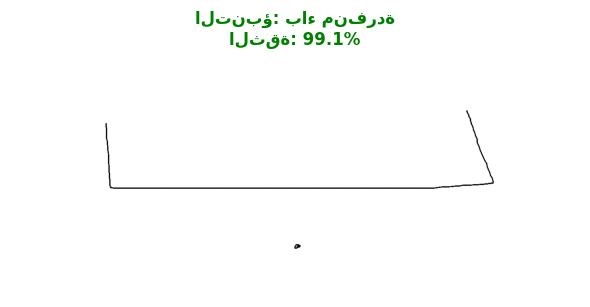


النتيجة: باء منفردة
الثقة: 99.08%



In [33]:
test_new_image(r"ضع رابط صورة عشوائية من خارج البيانات التي في المشروع")

فحص البيانات المحملة:



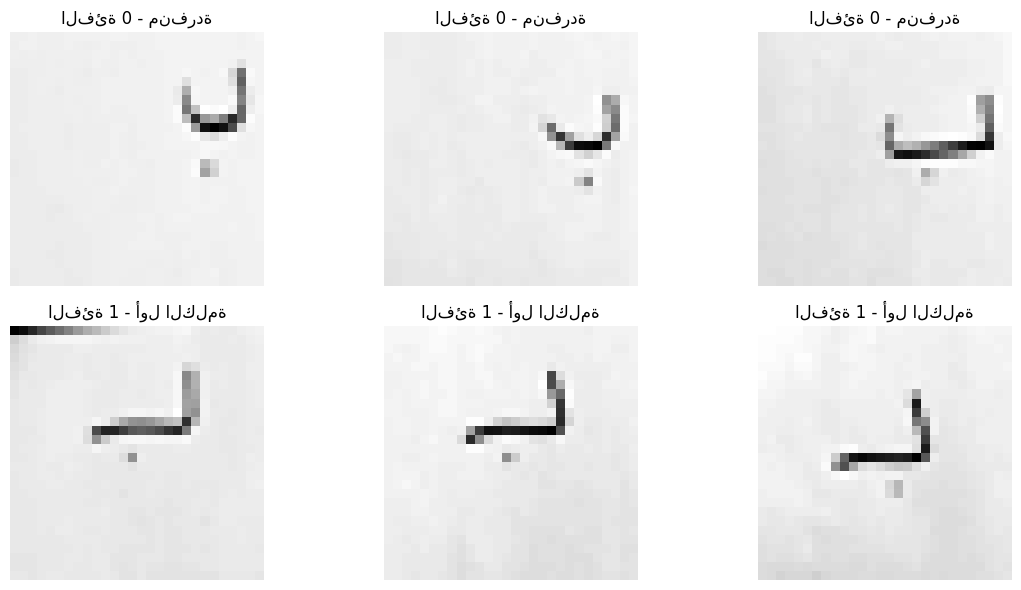


فحص التسميات المحملة:

عدد صور الفئة 0: 231
عدد صور الفئة 1: 231
إجمالي: 231

تحقق من التسميات:
هل التسميات تطابق الصور بشكل صحيح؟
الفئة 0 = حرف الباء المنفردة (اليمين)
الفئة 1 = حرف الباء أول الكلمة (اليسار)


In [34]:
##هذا قسم تحقق أن الفئات صحيحة

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = r'C:\Users\fares\Desktop\محتوى سياق\قواعد بيانات سياق\حرف الباء'
isolated_path = os.path.join(base_path, 'حرف الباء مفردًا')
beginning_path = os.path.join(base_path, 'حرف الباء أول الكلمة')

print("فحص البيانات المحملة:\n")

X_isolated_check = []
for filename in os.listdir(isolated_path)[:3]:
    img_path = os.path.join(isolated_path, filename)
    img = Image.open(img_path).convert('L')
    img = img.resize((28, 28))
    X_isolated_check.append(np.array(img))

X_beginning_check = []
for filename in os.listdir(beginning_path)[:3]:
    img_path = os.path.join(beginning_path, filename)
    img = Image.open(img_path).convert('L')
    img = img.resize((28, 28))
    X_beginning_check.append(np.array(img))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i in range(3):
    axes[0, i].imshow(X_isolated_check[i], cmap='gray')
    axes[0, i].set_title('الفئة 0 - منفردة')
    axes[0, i].axis('off')

for i in range(3):
    axes[1, i].imshow(X_beginning_check[i], cmap='gray')
    axes[1, i].set_title('الفئة 1 - أول الكلمة')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("\nفحص التسميات المحملة:\n")
print(f"عدد صور الفئة 0: {np.sum(y == 0)}")
print(f"عدد صور الفئة 1: {np.sum(y == 1)}")
print(f"إجمالي: {len(y)}")

print("\nتحقق من التسميات:")
print("هل التسميات تطابق الصور بشكل صحيح؟")
print("الفئة 0 = حرف الباء المنفردة (اليمين)")
print("الفئة 1 = حرف الباء أول الكلمة (اليسار)")